# Cardiovascular Disease Dataset — EDA Notebook

**Dataset source:** [Cardiovascular Disease dataset — Kaggle (sulianova)](https://www.kaggle.com/datasets/sulianova/cardiovascular-disease-dataset)

This notebook walks through:
1. Data loading & structure inspection
2. Data cleaning (missing values, duplicates, outliers, type fixes)
3. Univariate analysis
4. Bivariate & correlation analysis
5. Trend analysis
6. Key findings

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

PALETTE = ['#CA5995', '#FFB090', '#5D1C6A', '#7A2880']

## 1. Load & inspect

In [3]:
# Note: real Kaggle file uses semicolon delimiter
df = pd.read_csv('dataset.csv', sep=';')
print(f'Shape: {df.shape}')
df.head()

Shape: (70000, 13)


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB


In [5]:
print('Missing values:\n', df.isnull().sum())
print('\nDuplicate rows:', df.duplicated().sum())

Missing values:
 id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64

Duplicate rows: 0


## 2. Data cleaning

In [6]:
# Drop duplicates
df = df.drop_duplicates()

# Age: convert days -> years (raw dataset stores age in days)
df['age_years'] = (df['age'] / 365).round(0).astype(int)

# Fill missing numeric values with median
for col in ['height', 'weight', 'ap_hi', 'ap_lo']:
    df[col] = df[col].fillna(df[col].median())

# Remove physiologically impossible blood pressure readings
df = df[
    (df['ap_hi'] > 0) & (df['ap_hi'] <= 250) &
    (df['ap_lo'] > 0) & (df['ap_lo'] <= 200) &
    (df['ap_lo'] < df['ap_hi'])
]

# Clip extreme height/weight outliers (1st-99th percentile)
for col in ['height', 'weight']:
    lo, hi = df[col].quantile([0.01, 0.99])
    df = df[(df[col] >= lo) & (df[col] <= hi)]

# Engineer BMI
df['bmi'] = (df['weight'] / ((df['height']/100) ** 2)).round(1)

# Readable category labels
df['gender_label'] = df['gender'].map({1: 'Female', 2: 'Male'})
df['cholesterol_label'] = df['cholesterol'].map({1: 'Normal', 2: 'Above Normal', 3: 'Well Above Normal'})
df['cardio_label'] = df['cardio'].map({0: 'No Disease', 1: 'Has Disease'})

df.reset_index(drop=True, inplace=True)
print(f'Cleaned shape: {df.shape}')
df.head()

Cleaned shape: (66249, 18)


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years,bmi,gender_label,cholesterol_label,cardio_label
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0,50,22.0,Male,Normal,No Disease
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1,55,34.9,Female,Well Above Normal,Has Disease
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1,52,23.5,Female,Well Above Normal,Has Disease
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1,48,28.7,Male,Normal,Has Disease
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0,48,23.0,Female,Normal,No Disease


## 3. Statistical summary

In [7]:
df[['age_years','height','weight','bmi','ap_hi','ap_lo']].describe().round(2)

,age_years,height,weight,bmi,ap_hi,ap_lo
count,66249.00,66249.00,66249.00,66249.00,66249.00,66249.00
mean,53.34,164.46,73.76,27.32,126.62,81.26
std,6.76,7.31,12.84,4.76,16.55,9.48
min,30.00,147.00,48.00,15.10,16.00,6.00
25%,48.00,159.00,65.00,23.90,120.00,80.00
50%,54.00,165.00,72.00,26.30,120.00,80.00
75%,58.00,170.00,81.00,30.10,140.00,90.00
max,65.00,184.00,116.00,50.90,240.00,182.00


## 4. Univariate analysis

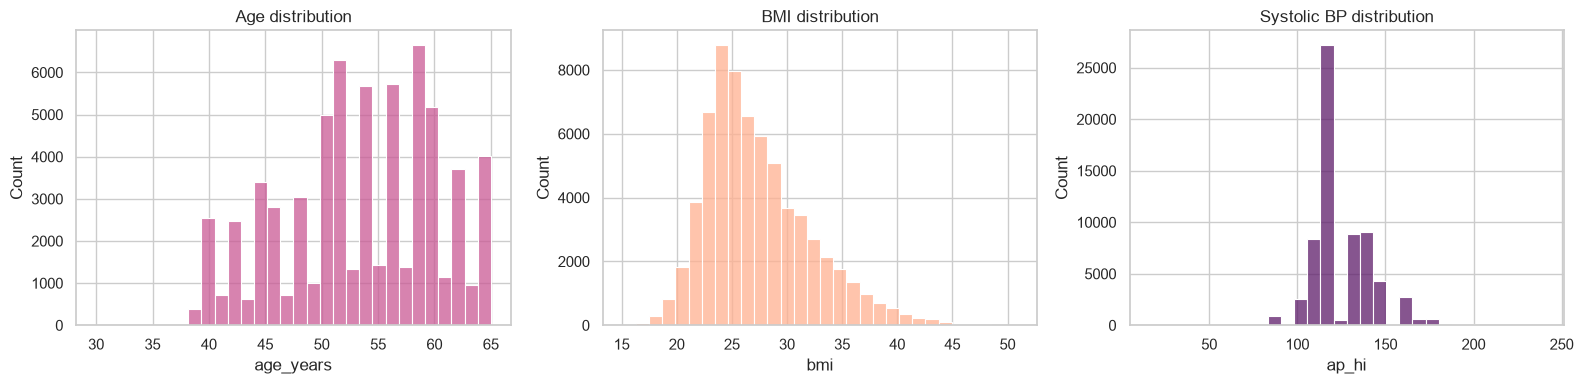

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.histplot(df['age_years'], bins=30, color=PALETTE[0], ax=axes[0])
axes[0].set_title('Age distribution')

sns.histplot(df['bmi'], bins=30, color=PALETTE[1], ax=axes[1])
axes[1].set_title('BMI distribution')

sns.histplot(df['ap_hi'], bins=30, color=PALETTE[2], ax=axes[2])
axes[2].set_title('Systolic BP distribution')

plt.tight_layout()
plt.show()

## 5. Bivariate & correlation analysis

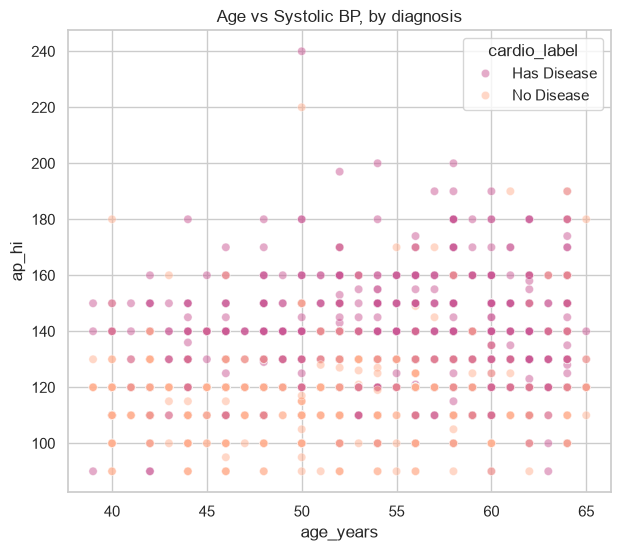

In [9]:
plt.figure(figsize=(7, 6))
sns.scatterplot(data=df.sample(min(2000, len(df))), x='age_years', y='ap_hi',
                hue='cardio_label', palette=PALETTE[:2], alpha=0.5)
plt.title('Age vs Systolic BP, by diagnosis')
plt.show()

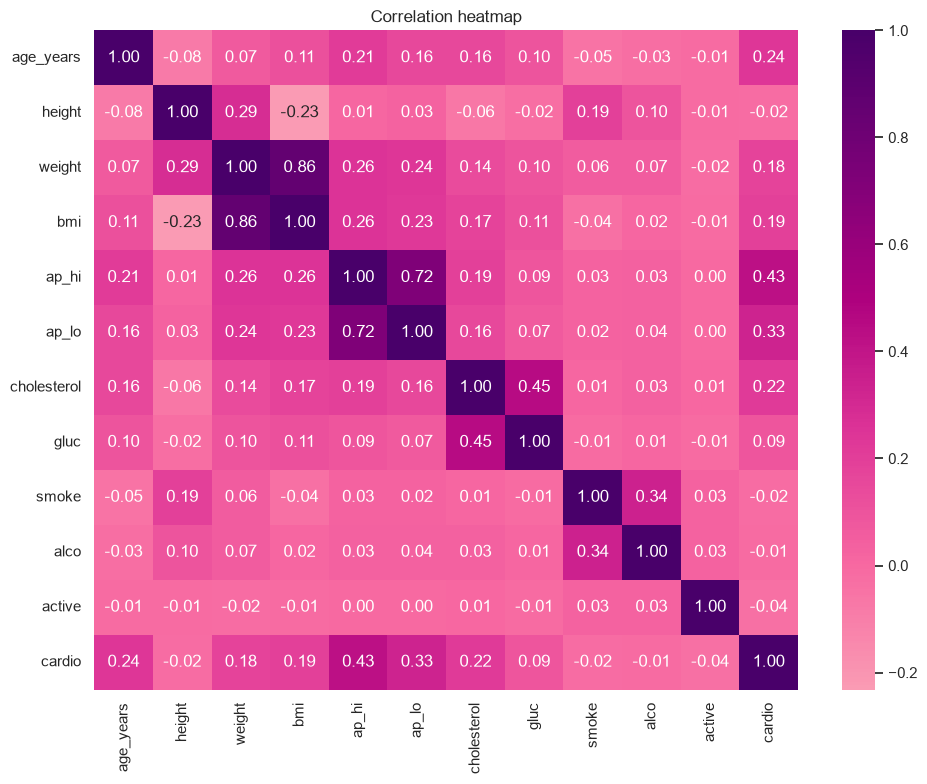

In [10]:
corr_cols = ['age_years','height','weight','bmi','ap_hi','ap_lo',
            'cholesterol','gluc','smoke','alco','active','cardio']
corr = df[corr_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdPu', center=0)
plt.title('Correlation heatmap')
plt.tight_layout()
plt.show()

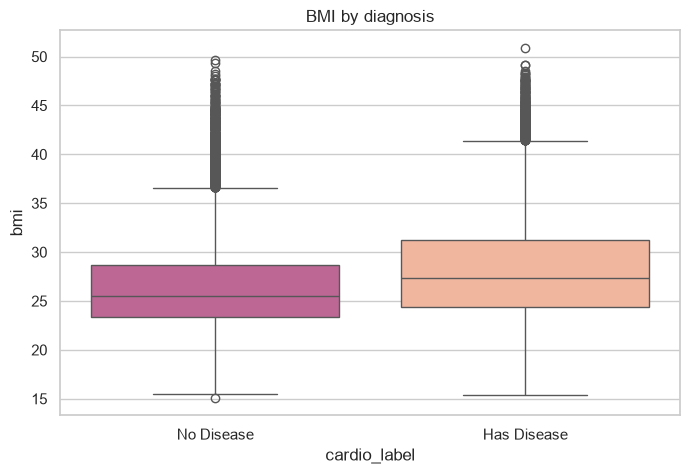

In [11]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='cardio_label', y='bmi', palette=PALETTE[:2])
plt.title('BMI by diagnosis')
plt.show()

## 6. Trend analysis

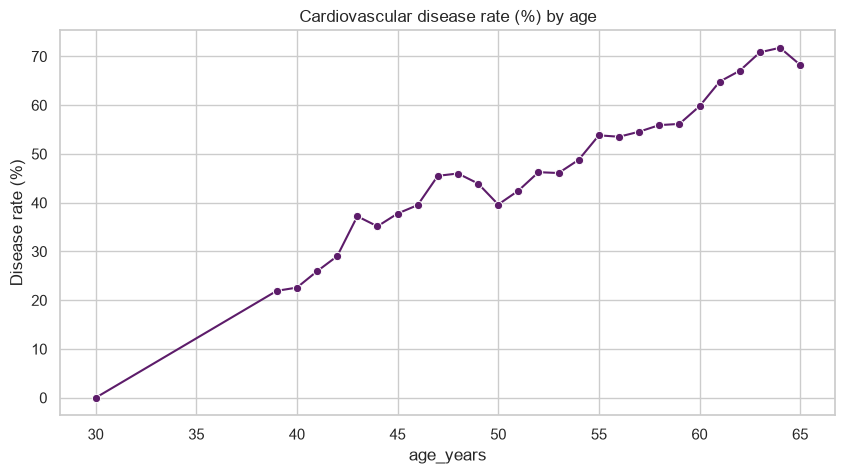

In [12]:
trend = df.groupby('age_years')['cardio'].mean().mul(100).reset_index()
plt.figure(figsize=(10, 5))
sns.lineplot(data=trend, x='age_years', y='cardio', marker='o', color=PALETTE[2])
plt.title('Cardiovascular disease rate (%) by age')
plt.ylabel('Disease rate (%)')
plt.show()

## 7. Key findings

- Which variable correlates most strongly with `cardio`?
- How much higher is the disease rate for high cholesterol vs normal?
- Does physical activity show a protective association?
- At what age does disease rate begin climbing noticeably?

**Answers:**
- **Strongest correlate:** `ap_hi` (systolic BP), r = 0.43 — the single strongest predictor, followed by `ap_lo` (diastolic, r = 0.33), `age_years` (r = 0.24), and `cholesterol` (r = 0.22).
- **Cholesterol effect:** disease rate is 43.5% at Normal cholesterol vs 76.2% at Well Above Normal — about **33 percentage points higher**, and 59.6% at Above Normal (a clear dose-response pattern).
- **Physical activity:** yes, modestly protective — 48.5% disease rate among active people vs 53.2% among inactive (**~4.7 pp lower**), a real but small effect compared to BP/cholesterol.
- **Age trend:** disease rate climbs steadily through the 40s and accelerates noticeably from about **age 43** onward (rate crosses ~37% and keeps rising), continuing up past 60% by the early 60s.